<a href="https://colab.research.google.com/github/Amruth-U-tech/Multi-Model-AI/blob/main/Colab-runs/tabular_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =============================================================================
# CELL 1 — Title & Project Info
# =============================================================================
# %% [markdown]
"""
# 📊 Multi-Modal AI — Tabular Metadata Analysis Pipeline
## Feature Quality, Variance Estimation & Predictive Signal Diagnostics

**Pipeline Overview:**
- Load preprocessed CSV datasets
- Validate required numerical and categorical columns
- Extract per-feature statistical summaries
- Compute correlations and detect skewness / outliers
- Generate visual distributions, boxplots, and heatmaps
- Print final insight summary for multimodal model readiness

**Goal:** Understand structured metadata quality and predictive signal strength
BEFORE multimodal fusion and model training.
"""

# =============================================================================
# CELL 2 — Install & Import Dependencies
# =============================================================================
# %%
# ── Uncomment if running on fresh Colab ──────────────────────────────────────
# !pip install pandas numpy matplotlib seaborn scipy tqdm --quiet

In [1]:
!pip install pandas numpy matplotlib seaborn scipy tqdm

In [4]:
import os
import warnings
import traceback
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm
import scipy

warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully.")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   matplotlib : {plt.matplotlib.__version__}")
print(f"   seaborn    : {sns.__version__}")
print(f"   scipy      : {scipy.__version__}")


✅ All libraries imported successfully.
   pandas     : 2.2.2
   numpy      : 2.0.2
   matplotlib : 3.10.0
   seaborn    : 0.13.2
   scipy      : 1.16.3


# =============================================================================
# CELL 3 — Configuration (Single Source of Truth — Edit Only Here)
# =============================================================================
# %%

In [19]:
# ── List of preprocessed CSV dataset paths ───────────────────────────────────
CSV_FILES = [
    "/content/drive/MyDrive/preprocessed-datasets/meta_cell_phones_and_accessories_processed.csv",
    "/content/drive/MyDrive/preprocessed-datasets/meta_digital_music_processed.csv",
    "/content/drive/MyDrive/preprocessed-datasets/handmade_products_processed.csv",
    "/content/drive/MyDrive/preprocessed-datasets/meta_amazon_fashion_processed.csv"
]

# ── Columns to analyze numerically ───────────────────────────────────────────
NUMERICAL_COLUMNS = [
    "price",
    "rating_number",
    "rating",
]

# ── Columns to analyze categorically ─────────────────────────────────────────
CATEGORICAL_COLUMNS = [
    "category",
]

# ── Target column for correlation analysis ────────────────────────────────────
TARGET_COLUMN = "rating"

# ── Outlier IQR fence multiplier ─────────────────────────────────────────────
IQR_MULTIPLIER = 1.5

print("✅ Configuration loaded.")
print(f"   CSV files          : {len(CSV_FILES)}")
print(f"   Numerical columns  : {NUMERICAL_COLUMNS}")
print(f"   Categorical columns: {CATEGORICAL_COLUMNS}")
print(f"   Target column      : {TARGET_COLUMN}")


✅ Configuration loaded.
   CSV files          : 4
   Numerical columns  : ['price', 'rating_number', 'rating']
   Categorical columns: ['category']
   Target column      : rating



# =============================================================================
# CELL 4 — Validation Helpers
# =============================================================================
# %%

In [6]:
def validate_dataset_inputs(
    csv_path: str,
    numerical_cols: List[str],
    categorical_cols: List[str],
) -> bool:
    """
    Validates all required inputs before processing a dataset.

    Checks:
      1. CSV file exists on disk
      2. At least one numerical column is present
      3. At least one categorical column is present (warning only, not fatal)

    Args:
        csv_path        : Absolute path to the CSV dataset file.
        numerical_cols  : List of expected numerical column names.
        categorical_cols: List of expected categorical column names.

    Returns:
        True if minimum requirements pass, False otherwise (caller should skip).
    """
    dataset_name = os.path.basename(csv_path)

    # ── Check 1: CSV file exists ──────────────────────────────────────────────
    if not os.path.exists(csv_path):
        print(f"   ❌ [SKIP] CSV file not found: {csv_path}")
        return False

    # ── Peek at columns ───────────────────────────────────────────────────────
    try:
        df_peek = pd.read_csv(csv_path, nrows=1)
    except Exception as e:
        print(f"   ❌ [SKIP] Cannot read CSV '{dataset_name}': {e}")
        return False

    available = set(df_peek.columns)

    # ── Check 2: At least one numerical column must be present ────────────────
    found_num = [c for c in numerical_cols if c in available]
    if not found_num:
        print(f"   ❌ [SKIP] None of the numerical columns found in '{dataset_name}'.")
        print(f"      Expected : {numerical_cols}")
        print(f"      Available: {list(available)}")
        return False

    missing_num = [c for c in numerical_cols if c not in available]
    if missing_num:
        print(f"   ⚠️  Numerical columns not found (will be skipped): {missing_num}")

    # ── Check 3: Categorical columns — warning only ───────────────────────────
    missing_cat = [c for c in categorical_cols if c not in available]
    if missing_cat:
        print(f"   ⚠️  Categorical columns not found (will be skipped): {missing_cat}")

    return True


print("✅ validate_dataset_inputs() defined.")


✅ validate_dataset_inputs() defined.


# =============================================================================
# CELL 5 — Numerical Feature Analyzer
# =============================================================================
# %%

In [7]:
def analyze_numerical_features(
    df: pd.DataFrame,
    numerical_cols: List[str],
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Computes a rich statistical summary for each numerical column.

    Metrics extracted per column:
      - count, missing, missing_pct
      - mean, median, std
      - coefficient_of_variation (std / mean * 100)
      - min, max, range
      - p5, p25, p75, p95
      - iqr
      - skewness
      - is_constant (zero-variance flag)

    Args:
        df             : Loaded dataset DataFrame.
        numerical_cols : List of numerical column names to analyze.

    Returns:
        num_stats_df   : DataFrame of per-column statistics.
        skipped_cols   : List of columns that could not be analyzed.
    """
    rows        = []
    skipped     = []
    valid_cols  = [c for c in numerical_cols if c in df.columns]

    for col in tqdm(valid_cols, desc="Analyzing numerical features"):
        series = pd.to_numeric(df[col], errors="coerce")
        total  = len(series)
        missing     = series.isna().sum()
        missing_pct = round(missing / total * 100, 2) if total > 0 else 0.0
        clean       = series.dropna()

        if clean.empty:
            skipped.append(col)
            continue

        mean   = clean.mean()
        std    = clean.std()
        cv     = round(std / mean * 100, 2) if mean != 0 else None
        p5     = clean.quantile(0.05)
        p25    = clean.quantile(0.25)
        p75    = clean.quantile(0.75)
        p95    = clean.quantile(0.95)
        iqr    = p75 - p25

        # ── Outliers via IQR fence ────────────────────────────────────────────
        lower_fence   = p25 - IQR_MULTIPLIER * iqr
        upper_fence   = p75 + IQR_MULTIPLIER * iqr
        outlier_count = ((clean < lower_fence) | (clean > upper_fence)).sum()
        outlier_pct   = round(outlier_count / len(clean) * 100, 2)

        rows.append({
            "column"          : col,
            "count"           : len(clean),
            "missing"         : missing,
            "missing_pct"     : missing_pct,
            "mean"            : round(mean, 4),
            "median"          : round(clean.median(), 4),
            "std"             : round(std, 4),
            "cv_pct"          : cv,
            "min"             : round(clean.min(), 4),
            "max"             : round(clean.max(), 4),
            "range"           : round(clean.max() - clean.min(), 4),
            "p5"              : round(p5, 4),
            "p25"             : round(p25, 4),
            "p75"             : round(p75, 4),
            "p95"             : round(p95, 4),
            "iqr"             : round(iqr, 4),
            "skewness"        : round(stats.skew(clean), 4),
            "outlier_count"   : int(outlier_count),
            "outlier_pct"     : outlier_pct,
            "is_constant"     : bool(std == 0),
        })

    num_stats_df = pd.DataFrame(rows) if rows else pd.DataFrame()
    return num_stats_df, skipped


print("✅ analyze_numerical_features() defined.")


✅ analyze_numerical_features() defined.


# =============================================================================
# CELL 6 — Categorical Feature Analyzer
# =============================================================================
# %%

In [8]:
def analyze_categorical_features(
    df: pd.DataFrame,
    categorical_cols: List[str],
) -> pd.DataFrame:
    """
    Computes frequency and diversity statistics for each categorical column.

    Metrics extracted per column:
      - total, missing, missing_pct
      - unique_count
      - dominant_category
      - dominant_ratio (fraction of rows held by top category)
      - entropy (Shannon entropy — diversity proxy)
      - top 5 value counts

    Works correctly for both single-category and multi-category datasets.

    Args:
        df               : Loaded dataset DataFrame.
        categorical_cols : List of categorical column names to analyze.

    Returns:
        cat_stats_df : DataFrame of per-column categorical statistics.
    """
    rows       = []
    valid_cols = [c for c in categorical_cols if c in df.columns]

    for col in valid_cols:
        series  = df[col].astype(str).replace("nan", pd.NA)
        total   = len(series)
        missing = series.isna().sum()
        missing_pct = round(missing / total * 100, 2) if total > 0 else 0.0
        clean   = series.dropna()

        if clean.empty:
            continue

        vc             = clean.value_counts()
        unique_count   = len(vc)
        dominant       = vc.index[0]
        dominant_ratio = round(vc.iloc[0] / len(clean), 4)

        # ── Shannon entropy ───────────────────────────────────────────────────
        probs   = vc / vc.sum()
        entropy = round(float(-np.sum(probs * np.log2(probs + 1e-12))), 4)

        rows.append({
            "column"          : col,
            "total"           : total,
            "missing"         : missing,
            "missing_pct"     : missing_pct,
            "unique_count"    : unique_count,
            "dominant_category": dominant,
            "dominant_ratio"  : dominant_ratio,
            "entropy_bits"    : entropy,
            "top5_counts"     : dict(vc.head(5)),
        })

    cat_stats_df = pd.DataFrame(rows) if rows else pd.DataFrame()
    return cat_stats_df


print("✅ analyze_categorical_features() defined.")


✅ analyze_categorical_features() defined.


# =============================================================================
# CELL 7 — Correlation Analyzer
# =============================================================================
# %%

In [9]:
def compute_correlation_matrix(
    df: pd.DataFrame,
    numerical_cols: List[str],
) -> Optional[pd.DataFrame]:
    """
    Computes a Pearson correlation matrix for all valid numerical columns.

    Skips constant columns and columns with insufficient non-null data.

    Args:
        df             : Loaded dataset DataFrame.
        numerical_cols : List of numerical column names.

    Returns:
        corr_matrix : Correlation DataFrame, or None if fewer than 2 valid columns.
    """
    valid_cols = []
    for col in numerical_cols:
        if col not in df.columns:
            continue
        series = pd.to_numeric(df[col], errors="coerce").dropna()
        if len(series) >= 2 and series.std() > 0:
            valid_cols.append(col)

    if len(valid_cols) < 2:
        print("   ⚠️  Fewer than 2 valid numerical columns — cannot compute correlation.")
        return None

    num_df      = df[valid_cols].apply(pd.to_numeric, errors="coerce")
    corr_matrix = num_df.corr(method="pearson")
    return corr_matrix


print("✅ compute_correlation_matrix() defined.")


✅ compute_correlation_matrix() defined.


# =============================================================================
# CELL 8 — Visualization Functions
# =============================================================================
# %%

In [10]:
def plot_numerical_distributions(
    df: pd.DataFrame,
    numerical_cols: List[str],
    dataset_name: str,
) -> None:
    """
    Generates a 2-row panel:
      Row 1 — Histogram with KDE for each numerical column
      Row 2 — Boxplot for each numerical column

    Args:
        df             : Loaded dataset DataFrame.
        numerical_cols : List of numerical column names.
        dataset_name   : Used as figure title.
    """
    valid_cols = [c for c in numerical_cols if c in df.columns]
    if not valid_cols:
        print("   ⚠️  No valid numerical columns — skipping distributions.")
        return

    n    = len(valid_cols)
    fig  = plt.figure(figsize=(n * 5, 9))
    fig.suptitle(
        f"📊 Numerical Feature Distributions — {dataset_name}",
        fontsize=14, fontweight="bold", y=1.01
    )
    gs = gridspec.GridSpec(2, n, figure=fig, hspace=0.45, wspace=0.35)

    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

    for i, col in enumerate(valid_cols):
        series = pd.to_numeric(df[col], errors="coerce").dropna()
        color  = colors[i % len(colors)]

        # ── Row 1: Histogram + KDE ────────────────────────────────────────────
        ax_hist = fig.add_subplot(gs[0, i])
        ax_hist.hist(series, bins=25, color=color, edgecolor="white", alpha=0.80, density=True)
        if len(series) > 2:
            kde_x = np.linspace(series.min(), series.max(), 200)
            try:
                kde   = stats.gaussian_kde(series)
                ax_hist.plot(kde_x, kde(kde_x), color="black", linewidth=1.5, label="KDE")
            except Exception:
                pass
        ax_hist.axvline(series.mean(),   color="red",    linestyle="--", linewidth=1.2, label=f"Mean: {series.mean():.2f}")
        ax_hist.axvline(series.median(), color="orange", linestyle="--", linewidth=1.2, label=f"Med: {series.median():.2f}")
        ax_hist.set_title(col, fontsize=11, fontweight="bold")
        ax_hist.set_xlabel("Value")
        ax_hist.set_ylabel("Density")
        ax_hist.legend(fontsize=7)
        ax_hist.grid(axis="y", alpha=0.3)

        # ── Row 2: Boxplot ────────────────────────────────────────────────────
        ax_box = fig.add_subplot(gs[1, i])
        ax_box.boxplot(series, patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.6),
                       medianprops=dict(color="black", linewidth=2),
                       flierprops=dict(marker="o", markerfacecolor="red", markersize=4, alpha=0.5))
        ax_box.set_title(f"{col} — Boxplot", fontsize=10, fontweight="bold")
        ax_box.set_ylabel("Value")
        ax_box.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"   ✅ Numerical distribution plots rendered for '{dataset_name}'.")


def plot_correlation_heatmap(
    corr_matrix: pd.DataFrame,
    dataset_name: str,
) -> None:
    """
    Renders a seaborn annotated correlation heatmap.

    Args:
        corr_matrix  : Pearson correlation DataFrame.
        dataset_name : Used as figure title.
    """
    if corr_matrix is None or corr_matrix.empty:
        print("   ⚠️  No correlation matrix — skipping heatmap.")
        return

    n   = len(corr_matrix)
    fig, ax = plt.subplots(figsize=(max(5, n * 1.8), max(4, n * 1.5)))
    sns.heatmap(
        corr_matrix,
        annot=True, fmt=".2f",
        cmap="coolwarm", center=0,
        vmin=-1, vmax=1,
        linewidths=0.5, linecolor="white",
        square=True, ax=ax,
        annot_kws={"size": 10},
    )
    ax.set_title(
        f"🔗 Pearson Correlation Heatmap — {dataset_name}",
        fontsize=13, fontweight="bold", pad=12
    )
    plt.tight_layout()
    plt.show()
    print(f"   ✅ Correlation heatmap rendered for '{dataset_name}'.")


def plot_categorical_distributions(
    df: pd.DataFrame,
    categorical_cols: List[str],
    dataset_name: str,
    top_n: int = 20,
) -> None:
    """
    Renders a bar chart of value frequencies for each categorical column.

    Args:
        df               : Loaded dataset DataFrame.
        categorical_cols : List of categorical column names.
        dataset_name     : Used as figure title.
        top_n            : Maximum categories to display per column.
    """
    valid_cols = [c for c in categorical_cols if c in df.columns]
    if not valid_cols:
        print("   ⚠️  No valid categorical columns — skipping frequency plots.")
        return

    for col in valid_cols:
        series = df[col].astype(str).replace("nan", pd.NA).dropna()
        vc     = series.value_counts().head(top_n)

        fig, ax = plt.subplots(figsize=(max(8, len(vc) * 0.9), 5))
        bars = ax.bar(range(len(vc)), vc.values, color="#4C72B0", edgecolor="white", alpha=0.85)
        ax.set_xticks(range(len(vc)))
        ax.set_xticklabels(vc.index, rotation=40, ha="right", fontsize=9)
        ax.set_title(
            f"🗂️  Category Frequency — '{col}' — {dataset_name}  (top {len(vc)})",
            fontsize=12, fontweight="bold"
        )
        ax.set_ylabel("Count")
        ax.grid(axis="y", alpha=0.3)

        # ── Annotate counts on bars ───────────────────────────────────────────
        for bar, val in zip(bars, vc.values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    str(val), ha="center", va="bottom", fontsize=8)

        plt.tight_layout()
        plt.show()
        print(f"   ✅ Categorical frequency plot rendered for '{col}'.")


print("✅ plot_numerical_distributions(), plot_correlation_heatmap(), plot_categorical_distributions() defined.")


✅ plot_numerical_distributions(), plot_correlation_heatmap(), plot_categorical_distributions() defined.


# =============================================================================
# CELL 9 — Insight Summary Printer
# =============================================================================
# %%

In [11]:
def print_insight_summary(
    num_stats_df    : pd.DataFrame,
    cat_stats_df    : pd.DataFrame,
    corr_matrix     : Optional[pd.DataFrame],
    target_column   : str,
    skipped_cols    : List[str],
    dataset_name    : str,
) -> None:
    """
    Prints a structured diagnostic summary answering 7 key questions
    about tabular metadata quality and multimodal model readiness.

    Questions answered:
      1. Do numerical features contain meaningful variance?
      2. Are features highly redundant?
      3. Are distributions heavily skewed?
      4. Are there problematic outliers?
      5. Is the tabular modality reliable?
      6. Does metadata correlate meaningfully with the target?
      7. Is the tabular modality weak, moderate, or strong?

    Args:
        num_stats_df  : DataFrame of per-numerical-column stats.
        cat_stats_df  : DataFrame of per-categorical-column stats.
        corr_matrix   : Pearson correlation DataFrame (can be None).
        target_column : Name of the target column.
        skipped_cols  : Columns that were skipped due to errors.
        dataset_name  : Dataset label for display.
    """
    print("\n" + "=" * 65)
    print(f"  🔍  TABULAR ANALYSIS INSIGHT SUMMARY — {dataset_name}")
    print("=" * 65)

    if skipped_cols:
        print(f"\n  ⚠️  Skipped columns (all-NaN or non-numeric): {skipped_cols}")

    # ── Q1: Numerical variance ────────────────────────────────────────────────
    print(f"\n  Q1 — Numerical Feature Variance:")
    if num_stats_df.empty:
        print("       ⚠️  No numerical stats available.")
    else:
        constant_cols  = num_stats_df[num_stats_df["is_constant"] == True]["column"].tolist()
        high_var_cols  = num_stats_df[num_stats_df["cv_pct"].notna() & (num_stats_df["cv_pct"] > 50)]["column"].tolist()
        low_var_cols   = num_stats_df[num_stats_df["cv_pct"].notna() & (num_stats_df["cv_pct"] <= 10)]["column"].tolist()

        for _, row in num_stats_df.iterrows():
            cv_str = f"{row['cv_pct']:.1f}%" if row["cv_pct"] is not None else "N/A (zero mean)"
            print(f"       {row['column']:<20} mean={row['mean']:<10.3f} std={row['std']:<10.3f} CV={cv_str}")

        if constant_cols:
            print(f"       ❌ Constant (zero variance): {constant_cols}")
        if high_var_cols:
            print(f"       ✅ High variance (CV > 50%): {high_var_cols}")
        if low_var_cols:
            print(f"       ⚠️  Low variance (CV ≤ 10%): {low_var_cols}")

        if not constant_cols and high_var_cols:
            var_verdict = "✅ STRONG VARIANCE — features show meaningful spread for model learning"
        elif constant_cols:
            var_verdict = f"⚠️  CONSTANT COLUMNS DETECTED — drop {constant_cols} before training"
        else:
            var_verdict = "🔶 MODERATE VARIANCE — usable but some features may contribute little signal"
        print(f"       Result → {var_verdict}")

    # ── Q2: Redundancy (correlation) ──────────────────────────────────────────
    print(f"\n  Q2 — Feature Redundancy (Pearson Correlation):")
    if corr_matrix is None or corr_matrix.empty:
        print("       ⚠️  Correlation matrix unavailable.")
    else:
        # Upper triangle, exclude diagonal
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr_pairs = [
            (c, r, round(upper.loc[r, c], 3))
            for c in upper.columns
            for r in upper.index
            if upper.loc[r, c] is not None and not pd.isna(upper.loc[r, c]) and abs(upper.loc[r, c]) > 0.80
        ]
        if high_corr_pairs:
            print(f"       ⚠️  Highly correlated pairs (|r| > 0.80):")
            for a, b, r in high_corr_pairs:
                print(f"          {a} ↔ {b}  r={r}")
            red_verdict = "⚠️  REDUNDANCY DETECTED — consider dropping one from each high-corr pair"
        else:
            print(f"       All feature pairs have |r| ≤ 0.80 — no strong redundancy detected.")
            red_verdict = "✅ LOW REDUNDANCY — features contribute distinct information"
        print(f"       Result → {red_verdict}")

    # ── Q3: Skewness ──────────────────────────────────────────────────────────
    print(f"\n  Q3 — Distribution Skewness:")
    if num_stats_df.empty:
        print("       ⚠️  No numerical stats available.")
    else:
        heavily_skewed = num_stats_df[num_stats_df["skewness"].abs() > 1.0]
        moderately_skewed = num_stats_df[
            (num_stats_df["skewness"].abs() > 0.5) &
            (num_stats_df["skewness"].abs() <= 1.0)
        ]
        for _, row in num_stats_df.iterrows():
            flag = "⚠️ " if abs(row["skewness"]) > 1.0 else ("🔶" if abs(row["skewness"]) > 0.5 else "✅")
            print(f"       {flag} {row['column']:<20} skewness={row['skewness']:>7.3f}")
        if not heavily_skewed.empty:
            skew_verdict = f"⚠️  HEAVY SKEW in {list(heavily_skewed['column'])} — log/sqrt transform recommended"
        elif not moderately_skewed.empty:
            skew_verdict = "🔶 MODERATE SKEW — consider scaling before training"
        else:
            skew_verdict = "✅ SKEW ACCEPTABLE — distributions are approximately symmetric"
        print(f"       Result → {skew_verdict}")

    # ── Q4: Outliers ──────────────────────────────────────────────────────────
    print(f"\n  Q4 — Outlier Presence (IQR × {IQR_MULTIPLIER} fence):")
    if num_stats_df.empty:
        print("       ⚠️  No numerical stats available.")
    else:
        for _, row in num_stats_df.iterrows():
            flag = "⚠️ " if row["outlier_pct"] > 10 else ("🔶" if row["outlier_pct"] > 3 else "✅")
            print(f"       {flag} {row['column']:<20} outliers={row['outlier_count']} ({row['outlier_pct']:.1f}%)")
        max_outlier_pct = num_stats_df["outlier_pct"].max()
        if max_outlier_pct > 10:
            out_verdict = "⚠️  SIGNIFICANT OUTLIERS — investigate and consider capping / robust scaling"
        elif max_outlier_pct > 3:
            out_verdict = "🔶 MODERATE OUTLIERS — winsorization or robust scaling may help"
        else:
            out_verdict = "✅ OUTLIER RATE ACCEPTABLE — no severe contamination detected"
        print(f"       Result → {out_verdict}")

    # ── Q5: Reliability (missing values) ─────────────────────────────────────
    print(f"\n  Q5 — Tabular Modality Reliability (Missing Values):")
    if num_stats_df.empty:
        print("       ⚠️  No numerical stats available.")
    else:
        for _, row in num_stats_df.iterrows():
            flag = "⚠️ " if row["missing_pct"] > 20 else ("🔶" if row["missing_pct"] > 5 else "✅")
            print(f"       {flag} {row['column']:<20} missing={row['missing']} ({row['missing_pct']:.1f}%)")
        max_miss = num_stats_df["missing_pct"].max()
        if max_miss > 20:
            rel_verdict = "⚠️  HIGH MISSINGNESS — imputation or column exclusion recommended"
        elif max_miss > 5:
            rel_verdict = "🔶 SOME MISSING DATA — simple imputation sufficient"
        else:
            rel_verdict = "✅ RELIABLE — missing value rate is negligible"
        print(f"       Result → {rel_verdict}")

    # ── Q6: Target correlation ────────────────────────────────────────────────
    print(f"\n  Q6 — Correlation with Target ('{target_column}'):")
    if corr_matrix is None or target_column not in (corr_matrix.columns if corr_matrix is not None else []):
        print(f"       ⚠️  Target column '{target_column}' not in correlation matrix.")
    else:
        target_corrs = corr_matrix[target_column].drop(labels=[target_column], errors="ignore")
        target_corrs = target_corrs.sort_values(key=abs, ascending=False)
        for feat, r in target_corrs.items():
            flag = "✅" if abs(r) > 0.30 else ("🔶" if abs(r) > 0.10 else "⚠️ ")
            print(f"       {flag} {feat:<20} r={r:>7.4f}")
        max_r = target_corrs.abs().max() if not target_corrs.empty else 0
        if max_r > 0.30:
            tgt_verdict = "✅ MEANINGFUL CORRELATION — features carry signal toward the target"
        elif max_r > 0.10:
            tgt_verdict = "🔶 WEAK CORRELATION — features have limited linear signal"
        else:
            tgt_verdict = "⚠️  NEAR-ZERO CORRELATION — tabular features may not explain target variance"
        print(f"       Result → {tgt_verdict}")

    # ── Q7: Overall tabular modality strength ─────────────────────────────────
    print(f"\n  Q7 — Overall Tabular Modality Strength:")
    signal_score = 0

    if not num_stats_df.empty:
        if num_stats_df["is_constant"].sum() == 0:                        signal_score += 1
        if (num_stats_df["cv_pct"].dropna() > 20).any():                  signal_score += 1
        if num_stats_df["missing_pct"].max() < 10:                        signal_score += 1

    if corr_matrix is not None and target_column in corr_matrix.columns:
        max_r = corr_matrix[target_column].drop(target_column, errors="ignore").abs().max()
        if max_r > 0.10:                                                   signal_score += 1

    print(f"       Composite signal score : {signal_score} / 4")
    if signal_score >= 3:
        final_verdict = "✅ STRONG TABULAR MODALITY — high-quality structured features, valuable for fusion"
    elif signal_score == 2:
        final_verdict = "🔶 MODERATE TABULAR MODALITY — usable with preprocessing improvements"
    else:
        final_verdict = "⚠️  WEAK TABULAR MODALITY — limited signal; prioritize image/text modalities"
    print(f"       Result → {final_verdict}")

    # ── Categorical summary ───────────────────────────────────────────────────
    if not cat_stats_df.empty:
        print(f"\n  📌 Categorical Feature Summary:")
        for _, row in cat_stats_df.iterrows():
            print(f"       Column  : {row['column']}")
            print(f"       Unique  : {row['unique_count']}  |  Dominant: '{row['dominant_category']}' ({row['dominant_ratio']*100:.1f}%)")
            print(f"       Entropy : {row['entropy_bits']:.3f} bits  |  Missing: {row['missing_pct']:.1f}%")
            if row["unique_count"] == 1:
                print(f"       ⚠️  Single-category column — no segmentation value for model training")
            elif row["dominant_ratio"] > 0.90:
                print(f"       ⚠️  Heavily imbalanced — one category dominates >90% of rows")
            else:
                print(f"       ✅ Adequate category diversity for segmentation")
            print()

    print("=" * 65)
    print("  ✅  Summary complete. Review results above before training.")
    print("=" * 65 + "\n")


print("✅ print_insight_summary() defined.")


✅ print_insight_summary() defined.


# =============================================================================
# CELL 10 — Single Dataset Analysis Pipeline
# =============================================================================
# %%


In [12]:
def analyze_dataset(
    csv_path          : str,
    numerical_cols    : List[str],
    categorical_cols  : List[str],
    target_column     : str,
) -> None:
    """
    Runs the full tabular analysis pipeline for a single dataset CSV.

    Workflow:
      1. Validate dataset inputs
      2. Load CSV dataset
      3. Report column coverage
      4. Analyze numerical features
      5. Analyze categorical features
      6. Compute correlation matrix
      7. Print statistics DataFrame preview
      8. Generate distribution + boxplot visualizations
      9. Render correlation heatmap
      10. Plot categorical frequency distributions
      11. Print final insight summary

    Args:
        csv_path         : Absolute path to the preprocessed CSV.
        numerical_cols   : List of numerical column names to analyze.
        categorical_cols : List of categorical column names to analyze.
        target_column    : Column name used as prediction target.
    """
    dataset_name = os.path.basename(csv_path)

    print("\n" + "=" * 65)
    print(f"  🗂️  Analyzing Dataset: {dataset_name}")
    print("=" * 65)

    # ── Step 1: Validate ──────────────────────────────────────────────────────
    print("\n🔍 Step 1 — Validating inputs...")
    if not validate_dataset_inputs(csv_path, numerical_cols, categorical_cols):
        print(f"   ⚠️  Skipping '{dataset_name}' due to validation failure.\n")
        return

    # ── Step 2: Load CSV ──────────────────────────────────────────────────────
    print("📂 Step 2 — Loading CSV dataset...")
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"   ❌ Failed to read CSV: {e}")
        return

    print(f"   ✅ Loaded {len(df)} rows × {len(df.columns)} columns.")
    print(f"   📌 Columns available: {list(df.columns)}")

    # ── Filter to columns that actually exist ─────────────────────────────────
    active_num = [c for c in numerical_cols   if c in df.columns]
    active_cat = [c for c in categorical_cols if c in df.columns]
    print(f"   📌 Active numerical   : {active_num}")
    print(f"   📌 Active categorical : {active_cat}")

    # ── Step 3: Numerical analysis ────────────────────────────────────────────
    print("\n📊 Step 3 — Extracting numerical feature statistics...")
    num_stats_df, skipped = analyze_numerical_features(df, active_num)
    print(f"   ✅ Numerical stats extracted for {len(num_stats_df)} columns.")
    if skipped:
        print(f"   ⚠️  Skipped (all-NaN): {skipped}")

    # ── Step 4: Categorical analysis ──────────────────────────────────────────
    print("\n🗂️  Step 4 — Extracting categorical feature statistics...")
    cat_stats_df = analyze_categorical_features(df, active_cat)
    print(f"   ✅ Categorical stats extracted for {len(cat_stats_df)} columns.")

    # ── Step 5: Correlation matrix ────────────────────────────────────────────
    print("\n🔗 Step 5 — Computing correlation matrix...")
    corr_matrix = compute_correlation_matrix(df, active_num)
    if corr_matrix is not None:
        print("   ✅ Correlation matrix computed.")
        print(corr_matrix.round(3).to_string())

    # ── Step 6: Stats preview ─────────────────────────────────────────────────
    if not num_stats_df.empty:
        print("\n📋 Step 6 — Numerical Statistics Preview:")
        preview_cols = [c for c in num_stats_df.columns if c not in ("top5_counts",)]
        print(num_stats_df[preview_cols].to_string(index=False))

    # ── Step 7: Distribution plots ────────────────────────────────────────────
    print("\n📈 Step 7 — Generating distribution and boxplot visualizations...")
    plot_numerical_distributions(df, active_num, dataset_name)

    # ── Step 8: Heatmap ───────────────────────────────────────────────────────
    print("\n🔥 Step 8 — Rendering correlation heatmap...")
    plot_correlation_heatmap(corr_matrix, dataset_name)

    # ── Step 9: Categorical plots ─────────────────────────────────────────────
    print("\n🗂️  Step 9 — Plotting categorical frequency distributions...")
    plot_categorical_distributions(df, active_cat, dataset_name)

    # ── Step 10: Insight summary ──────────────────────────────────────────────
    print_insight_summary(
        num_stats_df   = num_stats_df,
        cat_stats_df   = cat_stats_df,
        corr_matrix    = corr_matrix,
        target_column  = target_column,
        skipped_cols   = skipped,
        dataset_name   = dataset_name,
    )


print("✅ analyze_dataset() defined.")



✅ analyze_dataset() defined.


# =============================================================================
# CELL 11 — Main Multi-Dataset Pipeline
# =============================================================================
# %%

In [13]:
def run_pipeline(
    csv_files         : List[str],
    numerical_cols    : List[str],
    categorical_cols  : List[str],
    target_column     : str,
) -> None:
    """
    Main execution loop. Iterates through all configured CSV datasets
    and runs the full tabular analysis pipeline for each one.

    Args:
        csv_files        : List of CSV dataset paths.
        numerical_cols   : Numerical columns to analyze.
        categorical_cols : Categorical columns to analyze.
        target_column    : Target column for correlation analysis.
    """
    print("\n" + "=" * 65)
    print("  🚀  STARTING MULTI-DATASET TABULAR ANALYSIS PIPELINE")
    print(f"  Total datasets     : {len(csv_files)}")
    print(f"  Numerical columns  : {numerical_cols}")
    print(f"  Categorical columns: {categorical_cols}")
    print(f"  Target column      : {target_column}")
    print("=" * 65)

    pipeline_results = []

    for csv_path in csv_files:
        try:
            analyze_dataset(csv_path, numerical_cols, categorical_cols, target_column)
            pipeline_results.append({"file": os.path.basename(csv_path), "status": "✅ done"})
        except Exception as e:
            print(f"\n❌ Unexpected error in pipeline for '{csv_path}':")
            traceback.print_exc()
            pipeline_results.append({"file": os.path.basename(csv_path), "status": f"❌ error: {e}"})

    # ── Final run summary ─────────────────────────────────────────────────────
    print("\n" + "=" * 65)
    print("  📋  PIPELINE RUN SUMMARY")
    print("=" * 65)
    for r in pipeline_results:
        print(f"  {r['status']}  {r['file']}")
    print("\n✅ Tabular analysis pipeline complete.\n")


print("✅ run_pipeline() defined and ready.")


✅ run_pipeline() defined and ready.


# =============================================================================
# CELL 12 — Execute Pipeline
# =============================================================================
# %%


  🚀  STARTING MULTI-DATASET TABULAR ANALYSIS PIPELINE
  Total datasets     : 4
  Numerical columns  : ['price', 'rating_number', 'rating']
  Categorical columns: ['category']
  Target column      : rating

  🗂️  Analyzing Dataset: meta_cell_phones_and_accessories_processed.csv

🔍 Step 1 — Validating inputs...
📂 Step 2 — Loading CSV dataset...
   ✅ Loaded 1600 rows × 8 columns.
   📌 Columns available: ['asin', 'text', 'image_url', 'price', 'rating_number', 'category', 'rating', 'image_path']
   📌 Active numerical   : ['price', 'rating_number', 'rating']
   📌 Active categorical : ['category']

📊 Step 3 — Extracting numerical feature statistics...


Analyzing numerical features:   0%|          | 0/3 [00:00<?, ?it/s]

   ✅ Numerical stats extracted for 3 columns.

🗂️  Step 4 — Extracting categorical feature statistics...
   ✅ Categorical stats extracted for 1 columns.

🔗 Step 5 — Computing correlation matrix...
   ✅ Correlation matrix computed.
               price  rating_number  rating
price          1.000          0.171   0.021
rating_number  0.171          1.000   0.090
rating         0.021          0.090   1.000

📋 Step 6 — Numerical Statistics Preview:
       column  count  missing  missing_pct     mean  median       std  cv_pct  min     max    range    p5   p25    p75       p95   iqr  skewness  outlier_count  outlier_pct  is_constant
        price   1600        0          0.0  14.7110   12.99   17.0477  115.88 0.89   493.0   492.11 8.173 12.99  12.99   22.0115   0.0   18.4096            557        34.81        False
rating_number   1600        0          0.0 537.1719   24.00 3033.2670  564.67 1.00 58716.0 58715.00 1.000  5.75 142.25 1623.8000 136.5   13.3393            259        16.19       

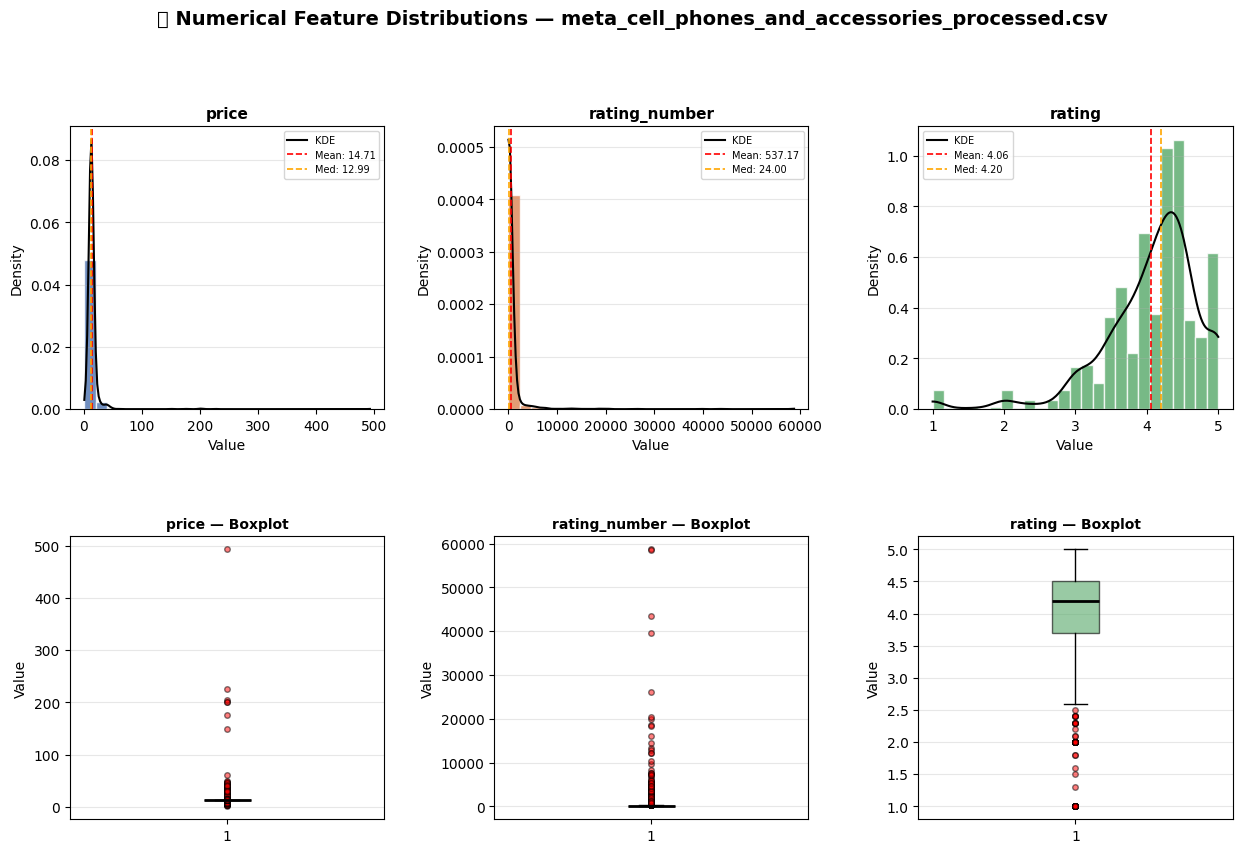

   ✅ Numerical distribution plots rendered for 'meta_cell_phones_and_accessories_processed.csv'.

🔥 Step 8 — Rendering correlation heatmap...


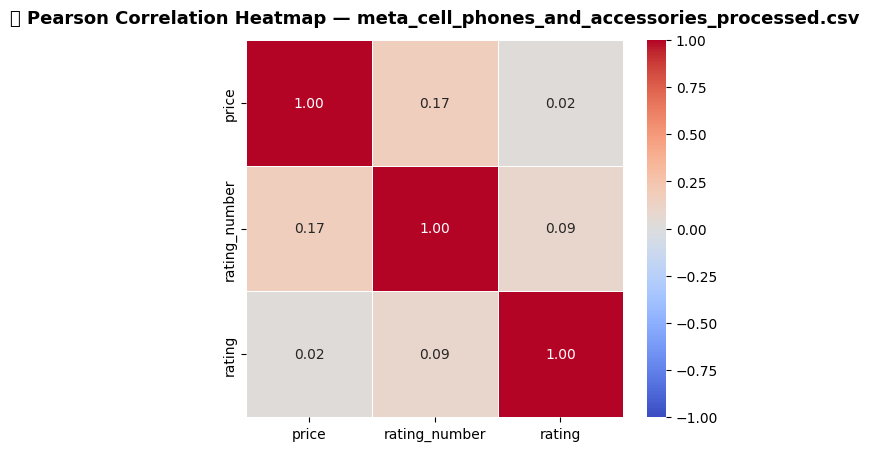

   ✅ Correlation heatmap rendered for 'meta_cell_phones_and_accessories_processed.csv'.

🗂️  Step 9 — Plotting categorical frequency distributions...


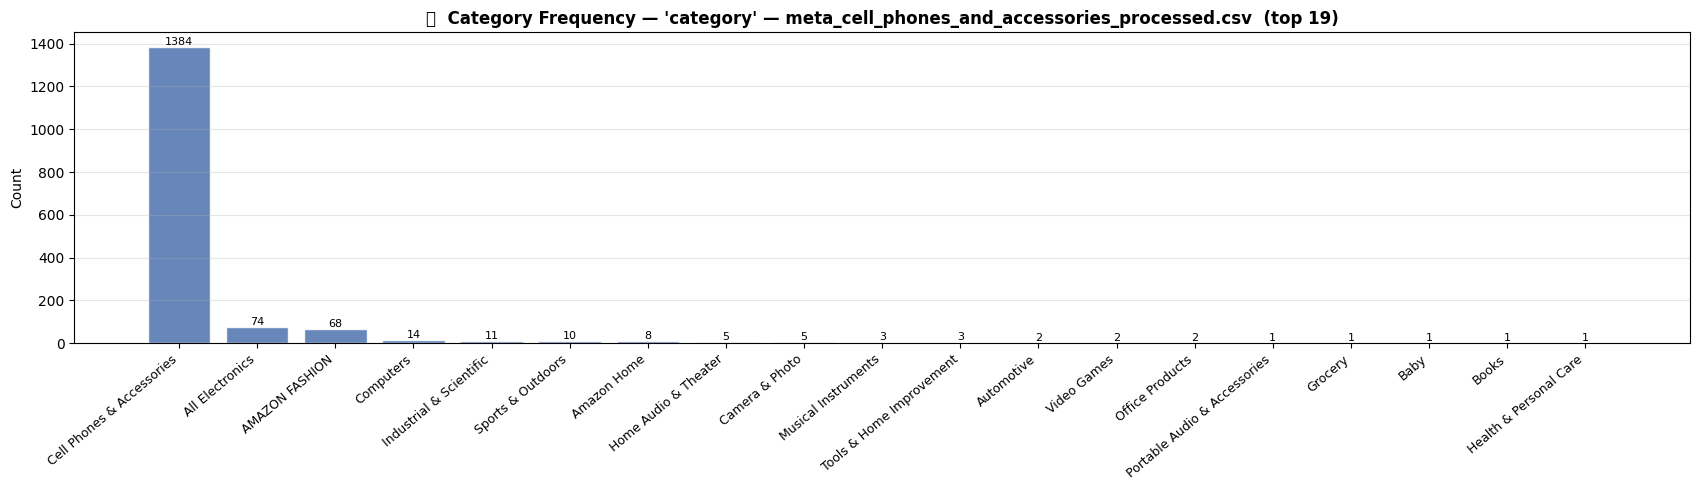

   ✅ Categorical frequency plot rendered for 'category'.

  🔍  TABULAR ANALYSIS INSIGHT SUMMARY — meta_cell_phones_and_accessories_processed.csv

  Q1 — Numerical Feature Variance:
       price                mean=14.711     std=17.048     CV=115.9%
       rating_number        mean=537.172    std=3033.267   CV=564.7%
       rating               mean=4.059      std=0.698      CV=17.2%
       ✅ High variance (CV > 50%): ['price', 'rating_number']
       Result → ✅ STRONG VARIANCE — features show meaningful spread for model learning

  Q2 — Feature Redundancy (Pearson Correlation):
       All feature pairs have |r| ≤ 0.80 — no strong redundancy detected.
       Result → ✅ LOW REDUNDANCY — features contribute distinct information

  Q3 — Distribution Skewness:
       ⚠️  price                skewness= 18.410
       ⚠️  rating_number        skewness= 13.339
       ⚠️  rating               skewness= -1.540
       Result → ⚠️  HEAVY SKEW in ['price', 'rating_number', 'rating'] — log/sqrt tran

Analyzing numerical features:   0%|          | 0/3 [00:00<?, ?it/s]

   ✅ Numerical stats extracted for 3 columns.

🗂️  Step 4 — Extracting categorical feature statistics...
   ✅ Categorical stats extracted for 1 columns.

🔗 Step 5 — Computing correlation matrix...
   ✅ Correlation matrix computed.
               price  rating_number  rating
price          1.000         -0.009   0.037
rating_number -0.009          1.000   0.023
rating         0.037          0.023   1.000

📋 Step 6 — Numerical Statistics Preview:
       column  count  missing  missing_pct     mean  median       std  cv_pct  min       max     range    p5    p25    p75     p95   iqr  skewness  outlier_count  outlier_pct  is_constant
        price   1600        0          0.0  29.9967   22.23   44.4839  148.30 1.34    911.08    909.74 5.207 18.255 25.015  79.952  6.76   11.3899            405        25.31        False
rating_number   1600        0          0.0 189.8094    4.00 2848.1882 1500.55 1.00 111099.00 111098.00 1.000  2.000 18.250 394.150 16.25   37.0554            271        16.94 

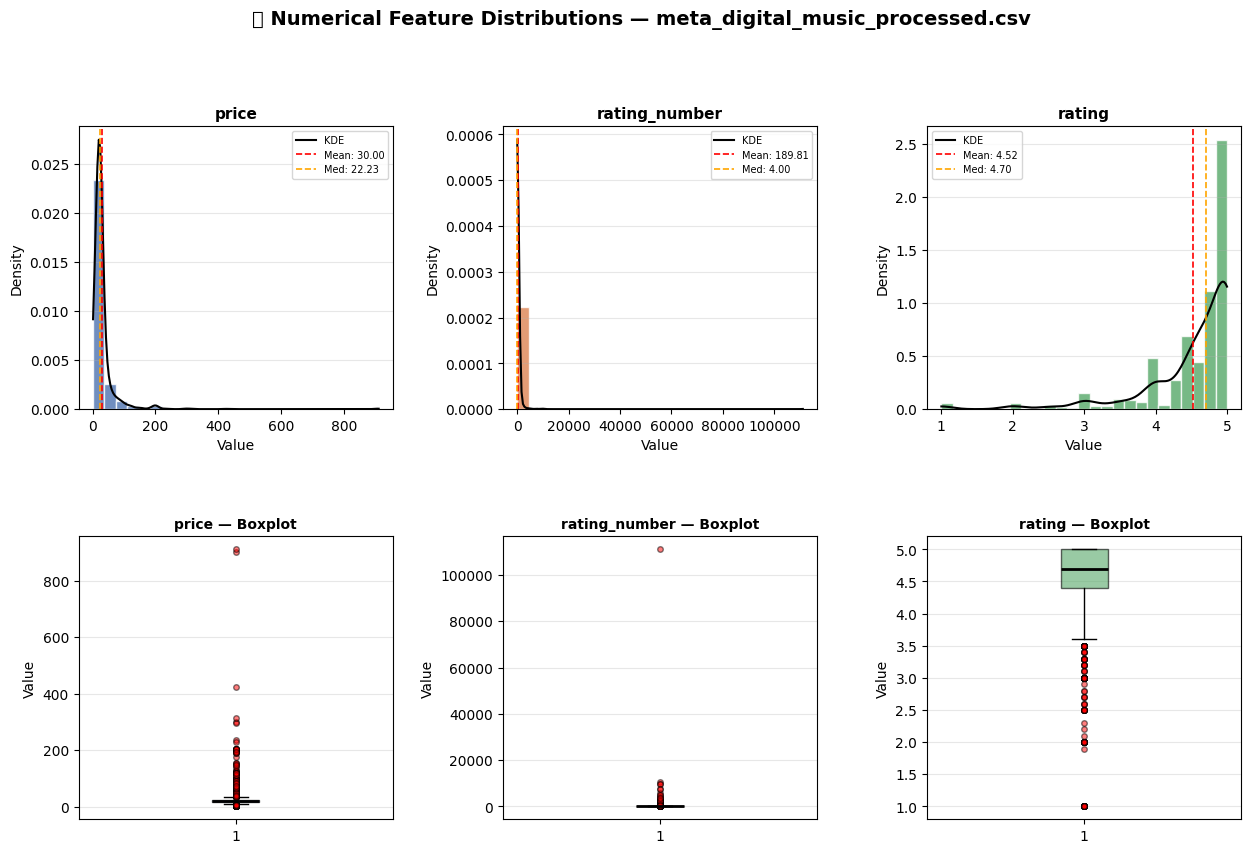

   ✅ Numerical distribution plots rendered for 'meta_digital_music_processed.csv'.

🔥 Step 8 — Rendering correlation heatmap...


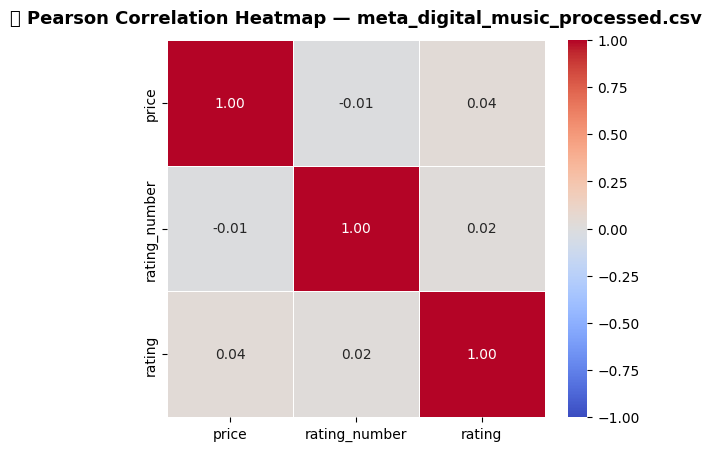

   ✅ Correlation heatmap rendered for 'meta_digital_music_processed.csv'.

🗂️  Step 9 — Plotting categorical frequency distributions...


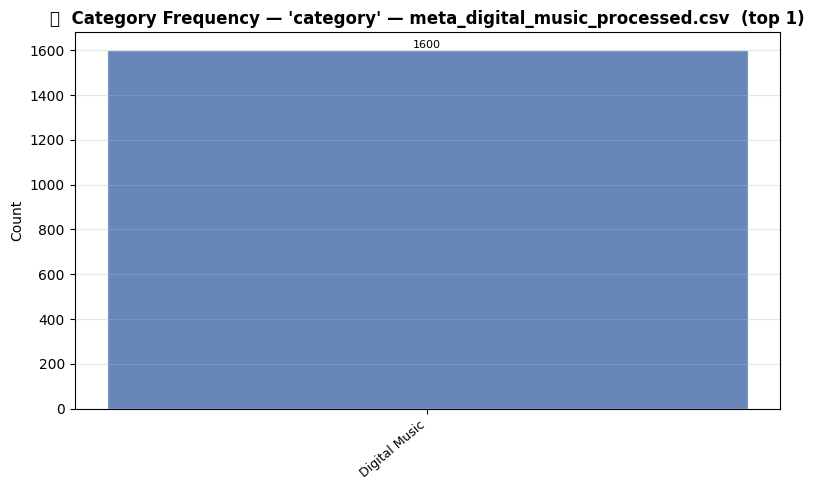

   ✅ Categorical frequency plot rendered for 'category'.

  🔍  TABULAR ANALYSIS INSIGHT SUMMARY — meta_digital_music_processed.csv

  Q1 — Numerical Feature Variance:
       price                mean=29.997     std=44.484     CV=148.3%
       rating_number        mean=189.809    std=2848.188   CV=1500.5%
       rating               mean=4.523      std=0.688      CV=15.2%
       ✅ High variance (CV > 50%): ['price', 'rating_number']
       Result → ✅ STRONG VARIANCE — features show meaningful spread for model learning

  Q2 — Feature Redundancy (Pearson Correlation):
       All feature pairs have |r| ≤ 0.80 — no strong redundancy detected.
       Result → ✅ LOW REDUNDANCY — features contribute distinct information

  Q3 — Distribution Skewness:
       ⚠️  price                skewness= 11.390
       ⚠️  rating_number        skewness= 37.055
       ⚠️  rating               skewness= -2.496
       Result → ⚠️  HEAVY SKEW in ['price', 'rating_number', 'rating'] — log/sqrt transform recomme

Analyzing numerical features:   0%|          | 0/3 [00:00<?, ?it/s]

   ✅ Numerical stats extracted for 3 columns.

🗂️  Step 4 — Extracting categorical feature statistics...
   ✅ Categorical stats extracted for 1 columns.

🔗 Step 5 — Computing correlation matrix...
   ✅ Correlation matrix computed.
               price  rating_number  rating
price          1.000         -0.023   0.040
rating_number -0.023          1.000  -0.003
rating         0.040         -0.003   1.000

📋 Step 6 — Numerical Statistics Preview:
       column  count  missing  missing_pct    mean  median      std  cv_pct  min    max  range   p5   p25   p75    p95   iqr  skewness  outlier_count  outlier_pct  is_constant
        price   1600        0          0.0 28.7142   19.99  59.8333  208.38  1.0 1645.0 1644.0 8.99 18.95 22.99 67.049  4.04   18.0072            468        29.25        False
rating_number   1600        0          0.0 26.8688    4.00 140.1934  521.77  1.0 3495.0 3494.0 1.00  2.00 14.00 78.000 12.00   15.4253            199        12.44        False
       rating   1600   

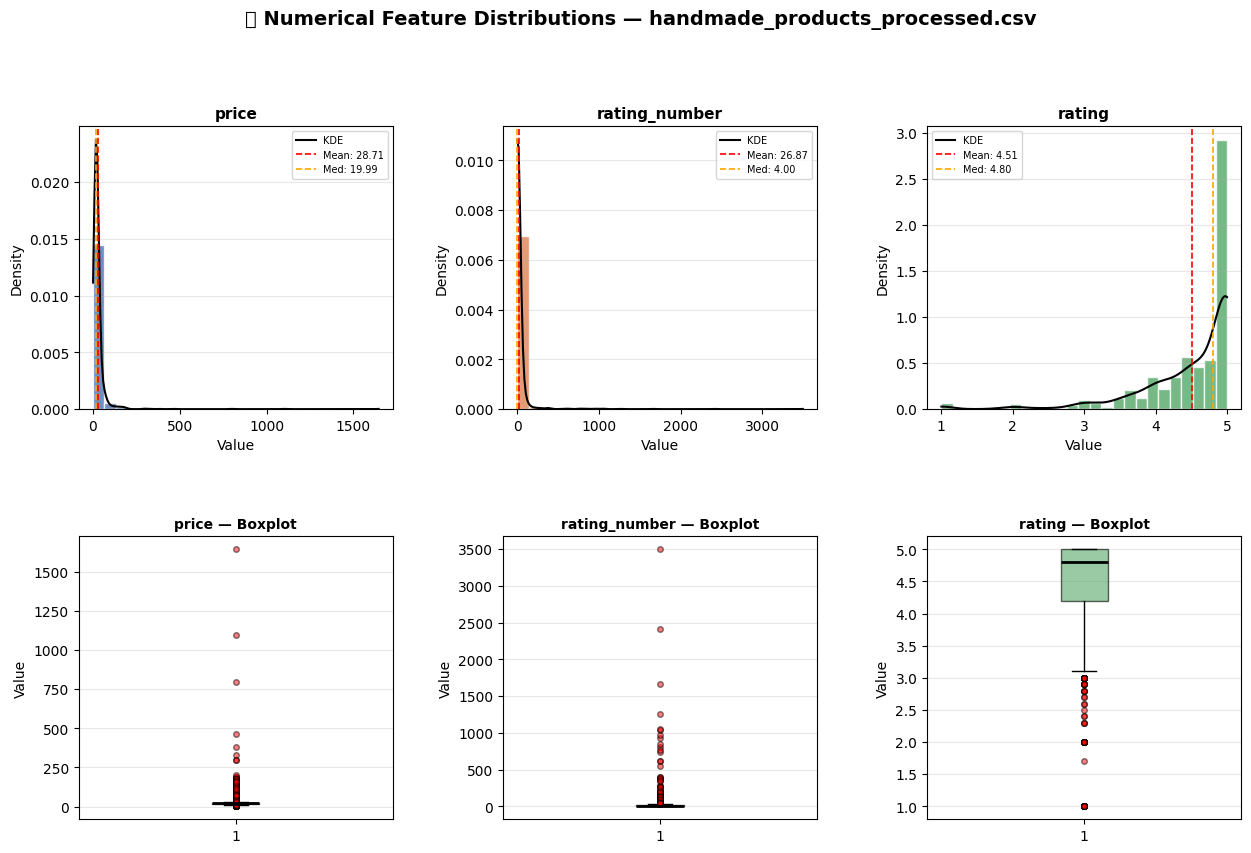

   ✅ Numerical distribution plots rendered for 'handmade_products_processed.csv'.

🔥 Step 8 — Rendering correlation heatmap...


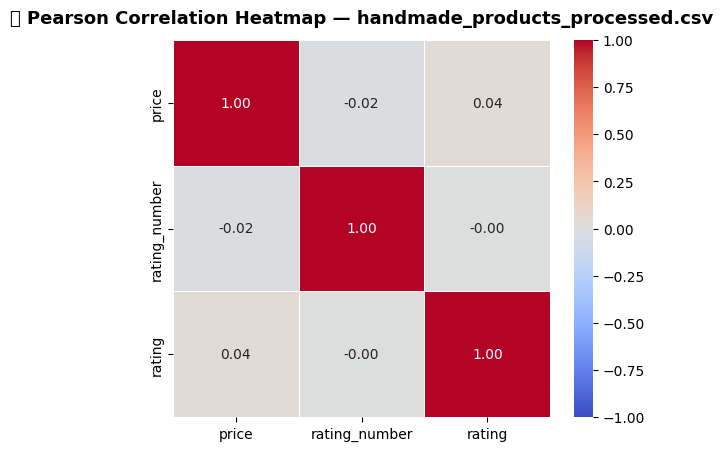

   ✅ Correlation heatmap rendered for 'handmade_products_processed.csv'.

🗂️  Step 9 — Plotting categorical frequency distributions...


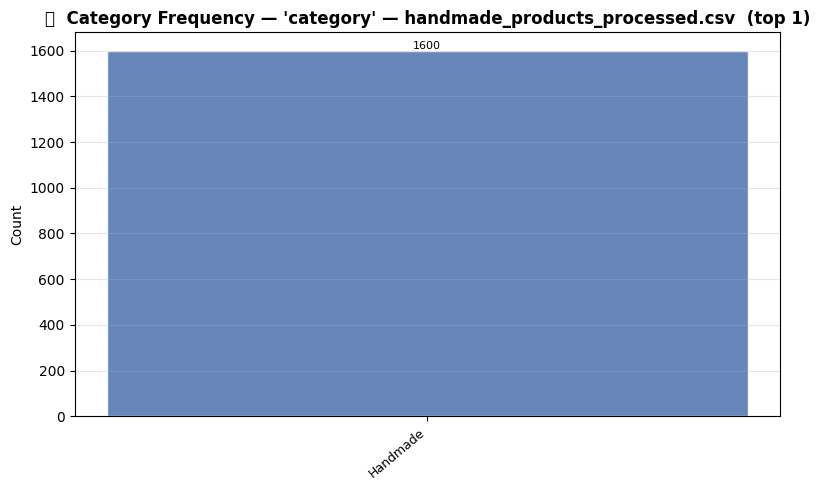

   ✅ Categorical frequency plot rendered for 'category'.

  🔍  TABULAR ANALYSIS INSIGHT SUMMARY — handmade_products_processed.csv

  Q1 — Numerical Feature Variance:
       price                mean=28.714     std=59.833     CV=208.4%
       rating_number        mean=26.869     std=140.193    CV=521.8%
       rating               mean=4.505      std=0.712      CV=15.8%
       ✅ High variance (CV > 50%): ['price', 'rating_number']
       Result → ✅ STRONG VARIANCE — features show meaningful spread for model learning

  Q2 — Feature Redundancy (Pearson Correlation):
       All feature pairs have |r| ≤ 0.80 — no strong redundancy detected.
       Result → ✅ LOW REDUNDANCY — features contribute distinct information

  Q3 — Distribution Skewness:
       ⚠️  price                skewness= 18.007
       ⚠️  rating_number        skewness= 15.425
       ⚠️  rating               skewness= -2.278
       Result → ⚠️  HEAVY SKEW in ['price', 'rating_number', 'rating'] — log/sqrt transform recommend

Analyzing numerical features:   0%|          | 0/3 [00:00<?, ?it/s]

   ✅ Numerical stats extracted for 3 columns.

🗂️  Step 4 — Extracting categorical feature statistics...
   ✅ Categorical stats extracted for 1 columns.

🔗 Step 5 — Computing correlation matrix...
   ✅ Correlation matrix computed.
               price  rating_number  rating
price          1.000          0.044   0.069
rating_number  0.044          1.000   0.035
rating         0.069          0.035   1.000

📋 Step 6 — Numerical Statistics Preview:
       column  count  missing  missing_pct    mean  median      std  cv_pct  min      max    range    p5   p25   p75    p95  iqr  skewness  outlier_count  outlier_pct  is_constant
        price   1600        0          0.0 20.6573   18.99  19.4528   94.17 1.73   399.99   398.26 15.99 18.99 18.99  21.99  0.0   15.8217            193        12.06        False
rating_number   1600        0          0.0 68.7144    4.00 944.0292 1373.85 1.00 36058.00 36057.00  1.00  2.00 12.00 102.10 10.0   34.9510            198        12.38        False
       rati

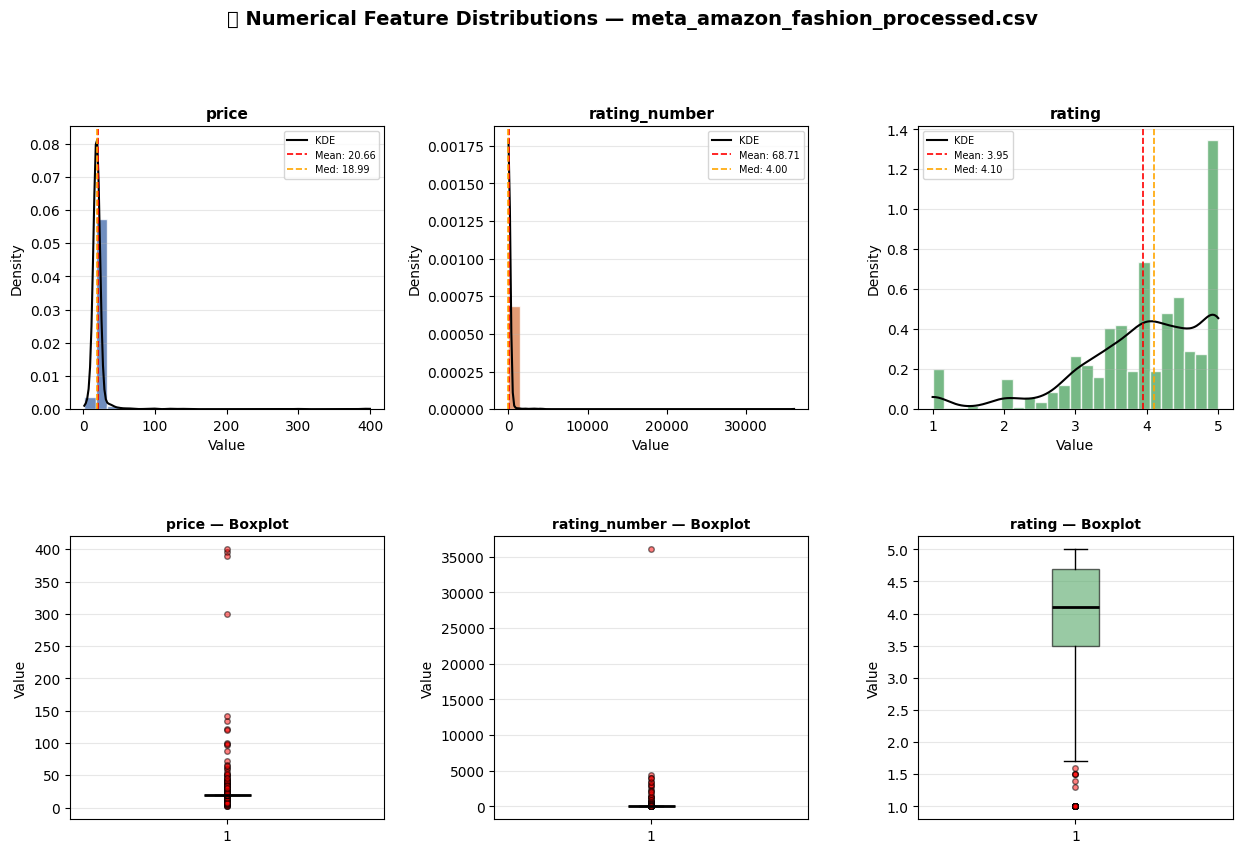

   ✅ Numerical distribution plots rendered for 'meta_amazon_fashion_processed.csv'.

🔥 Step 8 — Rendering correlation heatmap...


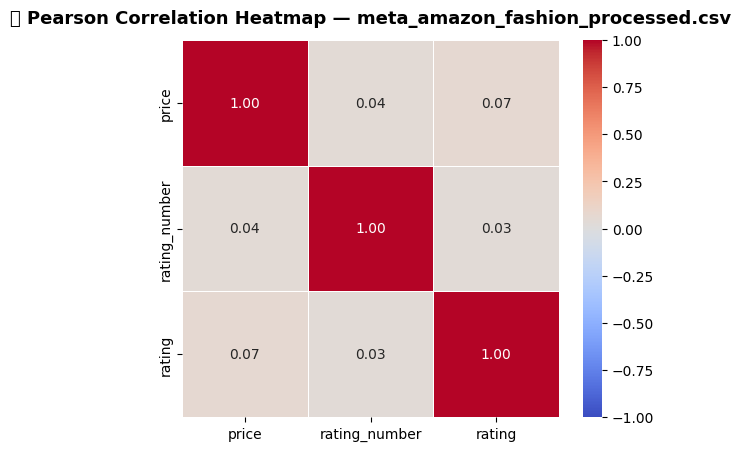

   ✅ Correlation heatmap rendered for 'meta_amazon_fashion_processed.csv'.

🗂️  Step 9 — Plotting categorical frequency distributions...


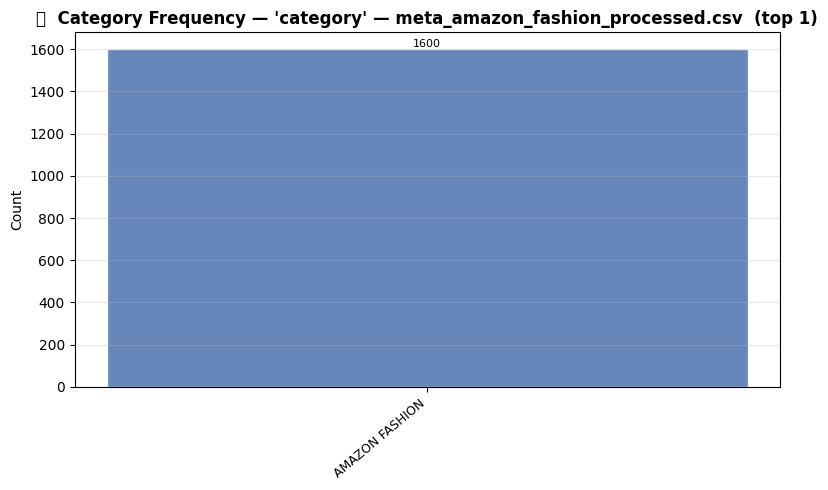

   ✅ Categorical frequency plot rendered for 'category'.

  🔍  TABULAR ANALYSIS INSIGHT SUMMARY — meta_amazon_fashion_processed.csv

  Q1 — Numerical Feature Variance:
       price                mean=20.657     std=19.453     CV=94.2%
       rating_number        mean=68.714     std=944.029    CV=1373.8%
       rating               mean=3.952      std=0.948      CV=24.0%
       ✅ High variance (CV > 50%): ['price', 'rating_number']
       Result → ✅ STRONG VARIANCE — features show meaningful spread for model learning

  Q2 — Feature Redundancy (Pearson Correlation):
       All feature pairs have |r| ≤ 0.80 — no strong redundancy detected.
       Result → ✅ LOW REDUNDANCY — features contribute distinct information

  Q3 — Distribution Skewness:
       ⚠️  price                skewness= 15.822
       ⚠️  rating_number        skewness= 34.951
       ⚠️  rating               skewness= -1.160
       Result → ⚠️  HEAVY SKEW in ['price', 'rating_number', 'rating'] — log/sqrt transform recomme

In [20]:
run_pipeline(
    csv_files        = CSV_FILES,
    numerical_cols   = NUMERICAL_COLUMNS,
    categorical_cols = CATEGORICAL_COLUMNS,
    target_column    = TARGET_COLUMN,
)